# Load Data (Eurostat API)

## Inflation

In [1]:
import requests

url = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/prc_hicp_manr?lang=EN"
params = {"lang":"EN"}

r = requests.get(url, params = params, timeout = 30)
r.raise_for_status()

data = r.json()
print(type(data))

<class 'dict'>


In [2]:
print(data.keys())

dict_keys(['version', 'class', 'label', 'source', 'updated', 'value', 'status', 'id', 'size', 'dimension', 'extension'])


### Exploring data

In [3]:
print(data.get("id"))

['freq', 'unit', 'coicop', 'geo', 'time']


In [4]:
print(data.get("label"))

HICP - monthly data (annual rate of change)


In [5]:
print(data.get("version"))

2.0


In [6]:
print(data.get("class"))

dataset


In [7]:
print(data.get("updated"))

2026-02-06T23:00:00+0100


In [8]:
print(data.get("size"))

[1, 1, 467, 45, 348]


---

### Filter countries:

#### ES, DE, FR, IT

### Filter time range:

#### 2015-01 a 2023-12

In [9]:

params = [
    ("lang", "EN"),
    ("geo", "ES"),
    ("geo", "DE"),
    ("geo", "FR"),
    ("geo", "IT"),   
    ("sinceTimePeriod", "2015-01"),  
    ("untilTimePeriod", "2023-12"),  
]

r = requests.get(url, params =params)
data = r.json()


In [10]:
print(data.keys())

dict_keys(['version', 'class', 'label', 'source', 'updated', 'value', 'status', 'id', 'size', 'dimension', 'extension'])


In [11]:
print(data.get("size"))  #Here we can see that the data got reduced accordingly to our scope

[1, 1, 467, 4, 108]


---

### Make the data a table (JSON-stat)

#### Double checked the keys for creating the table

In [12]:
print(data["dimension"].keys())

dict_keys(['freq', 'unit', 'coicop', 'geo', 'time'])


In [13]:
print(data["dimension"]["geo"].keys())

dict_keys(['label', 'category'])


In [14]:
print(data["dimension"]["time"].keys())

dict_keys(['label', 'category'])


#### Get the categories to ensure all the info is still there

In [15]:
ids = data["id"]

for dimension in ids:
    print("\nDIMENSION:", dimension)
    print("codes:", list(data["dimension"][dimension]["category"]["index"].keys())[:10])


DIMENSION: freq
codes: ['M']

DIMENSION: unit
codes: ['RCH_A']

DIMENSION: coicop
codes: ['CP00', 'CP01', 'CP011', 'CP0111', 'CP01111', 'CP01112', 'CP01113', 'CP01114', 'CP01115', 'CP01116']

DIMENSION: geo
codes: ['DE', 'ES', 'FR', 'IT']

DIMENSION: time
codes: ['2015-01', '2015-02', '2015-03', '2015-04', '2015-05', '2015-06', '2015-07', '2015-08', '2015-09', '2015-10']


In [ ]:
'''
Call the API again and filter the CP00 to save the final data frame
'''

In [16]:
params = [
    ("lang", "EN"),
    ("geo", "ES"),
    ("geo", "DE"),
    ("geo", "FR"),
    ("geo", "IT"),
    ("coicop", "CP00"),
    ("sinceTimePeriod", "2015-01"),
    ("untilTimePeriod", "2023-12"),
]

response = requests.get(url, params=params, timeout=30)
response.raise_for_status()
data_inflation = response.json()

In [17]:
print(data_inflation.keys())

dict_keys(['version', 'class', 'label', 'source', 'updated', 'value', 'id', 'size', 'dimension', 'extension'])


In [18]:
print(data_inflation.get("size"))

[1, 1, 1, 4, 108]


In [19]:
print(data_inflation.get("id"))

['freq', 'unit', 'coicop', 'geo', 'time']


In [20]:
ids = data_inflation["id"]

for dimension in ids:
    print("\nDIMENSION:", dimension)
    print("codes:", list(data_inflation["dimension"][dimension]["category"]["index"].keys())[:10])


DIMENSION: freq
codes: ['M']

DIMENSION: unit
codes: ['RCH_A']

DIMENSION: coicop
codes: ['CP00']

DIMENSION: geo
codes: ['DE', 'ES', 'FR', 'IT']

DIMENSION: time
codes: ['2015-01', '2015-02', '2015-03', '2015-04', '2015-05', '2015-06', '2015-07', '2015-08', '2015-09', '2015-10']


#### Create Dataframe

In [21]:
import pandas as pd
import itertools

ids = data_inflation["id"]
values_obj = data_inflation["value"]

#Obtain codes sorted according to index

dim_codes = {}

for dim in ids:
    cat_index = data["dimension"][dim]["category"]["index"]
    ordered_codes = [code for code, value in sorted(cat_index.items(),key=lambda x:x[1])]
    dim_codes[dim] = ordered_codes

#Generate the table with all the possible combinations
all_combinations = list(itertools.product(*(dim_codes[dim] for dim in ids)))

#Build each row

rows = []

for i, combo in enumerate (all_combinations):
    row = dict(zip(ids,combo))

    if isinstance(values_obj, dict):
        row["value"]= values_obj.get(str(i))
    else:
        row["value"]= values_obj[i] if i < len(values_obj) else None

    rows.append(row)

df = pd.DataFrame(rows)

In [22]:
print(df.head())

  freq   unit coicop geo     time  value
0    M  RCH_A   CP00  DE  2015-01   -0.5
1    M  RCH_A   CP00  DE  2015-02   -0.2
2    M  RCH_A   CP00  DE  2015-03    0.3
3    M  RCH_A   CP00  DE  2015-04    1.0
4    M  RCH_A   CP00  DE  2015-05    1.6


In [23]:
print(df.shape)

(201744, 6)


---

## Clean dataset in pandas

In [24]:
#Rename columns

df = df.rename(columns = {
    "geo": "country",
    "time": "date",
    "value": "inflation"
})

In [25]:
df.head()

,freq,unit,coicop,country,date,inflation
0,M,RCH_A,CP00,DE,2015-01,-0.5
1,M,RCH_A,CP00,DE,2015-02,-0.2
2,M,RCH_A,CP00,DE,2015-03,0.3
3,M,RCH_A,CP00,DE,2015-04,1.0
4,M,RCH_A,CP00,DE,2015-05,1.6


In [26]:
#Save only Date, Country and Inflation

df = df[["date","country","inflation"]].copy()

df.head(10)

,date,country,inflation
0,2015-01,DE,-0.5
1,2015-02,DE,-0.2
2,2015-03,DE,0.3
3,2015-04,DE,1.0
4,2015-05,DE,1.6
5,2015-06,DE,1.1
6,2015-07,DE,1.3
7,2015-08,DE,1.1
8,2015-09,DE,0.8
9,2015-10,DE,1.2


In [27]:
df["country"].unique()

array(['DE', 'ES', 'FR', 'IT'], dtype=object)

In [28]:
#Standardize names inside country, dates and inflation rates
df["date"] = pd.to_datetime(df["date"], errors = "coerce").dt.to_period("M").astype(str)
df["country"] = df["country"].str.upper()
df["inflation"] = pd.to_numeric(df["inflation"], errors = "coerce")

In [29]:
#Clean nules
df.dropna(subset = ["date","country","inflation"])
#Clean duplicates
df.drop_duplicates(subset = ["date","country"])
#Sort values per country and date
df.sort_values(["country","date"]).reset_index(drop=True)


,date,country,inflation
0,2015-01,DE,-0.5
1,2015-01,DE,NaN
2,2015-01,DE,NaN
3,2015-01,DE,NaN
4,2015-01,DE,NaN
...,...,...,...
201739,2023-12,IT,NaN
201740,2023-12,IT,NaN
201741,2023-12,IT,NaN
201742,2023-12,IT,NaN


In [30]:
print(df.shape)

(201744, 3)


In [31]:
df.drop_duplicates(subset = ["date","country"])

,date,country,inflation
0,2015-01,DE,-0.5
1,2015-02,DE,-0.2
2,2015-03,DE,0.3
3,2015-04,DE,1.0
4,2015-05,DE,1.6
...,...,...,...
427,2023-08,IT,5.5
428,2023-09,IT,5.6
429,2023-10,IT,1.8
430,2023-11,IT,0.6


In [32]:
df = df.drop_duplicates(subset=["date", "country"]).copy()

In [33]:
print(df.shape)

print("Duplicates (date only):", df.duplicated(["date"]).sum())
print("Duplicates (date + country):", df.duplicated(["date", "country"]).sum())

(432, 3)
Duplicates (date only): 324
Duplicates (date + country): 0


## Save Dataset clean

In [34]:
df.to_csv("inflation_clean.csv", index=False)

In [35]:
import pandas as pd

check = pd.read_csv("inflation_clean.csv")
print(check.shape)
print(check.duplicated(["date", "country"]).sum())
print(check.head())

(432, 3)
0
      date country  inflation
0  2015-01      DE       -0.5
1  2015-02      DE       -0.2
2  2015-03      DE        0.3
3  2015-04      DE        1.0
4  2015-05      DE        1.6


### View distributions

In [36]:
df.describe()

,inflation
count,432.000000
mean,2.260417
std,2.849949
min,-1.500000
25%,0.300000
50%,1.300000
75%,2.900000
max,12.600000


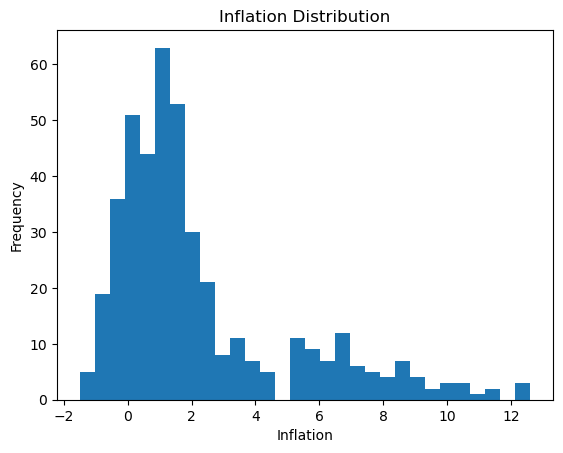

In [37]:
import matplotlib.pyplot as plt

plt.hist(df["inflation"], bins=30)
plt.title("Inflation Distribution")
plt.xlabel("Inflation")
plt.ylabel("Frequency")
plt.show()

Inflation shows a **right distribution**, with most values concentrated at lower levels and occasional high spikes.

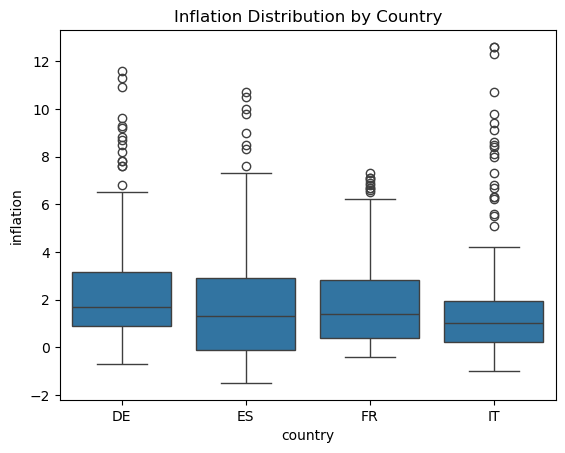

In [38]:
import seaborn as sns

sns.boxplot(x="country", y="inflation", data=df)
plt.title("Inflation Distribution by Country")
plt.show()

Average inflation levels are relatively similar across countries, but variability differs. **Spain** and **Italy** show wider distributions, indicating **higher inflation variability**.

In [39]:
#Find outliers (We can find specific dates that influenciated the peaks)

Q1 = df["inflation"].quantile(0.25)
Q3 = df["inflation"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df["inflation"] < Q1 - 1.5 * IQR) |
    (df["inflation"] > Q3 + 1.5 * IQR)
]

print(outliers.head(15))

        date country  inflation
86   2022-03      DE        7.6
87   2022-04      DE        7.8
88   2022-05      DE        8.7
89   2022-06      DE        8.2
90   2022-07      DE        8.5
91   2022-08      DE        8.8
92   2022-09      DE       10.9
93   2022-10      DE       11.6
94   2022-11      DE       11.3
95   2022-12      DE        9.6
96   2023-01      DE        9.2
97   2023-02      DE        9.3
98   2023-03      DE        7.8
99   2023-04      DE        7.6
193  2022-02      ES        7.6


**2022** - Has hight peaks of inflation (COVID? Review other possibilities)

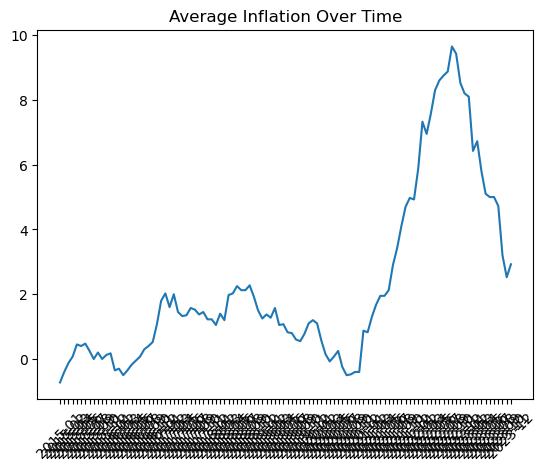

In [40]:
plt.plot(df.groupby("date")["inflation"].mean())
plt.xticks(rotation=45)
plt.title("Average Inflation Over Time")
plt.show()

---
### Data visualization adjusted

In [41]:
df["date"] = pd.to_datetime(df["date"])

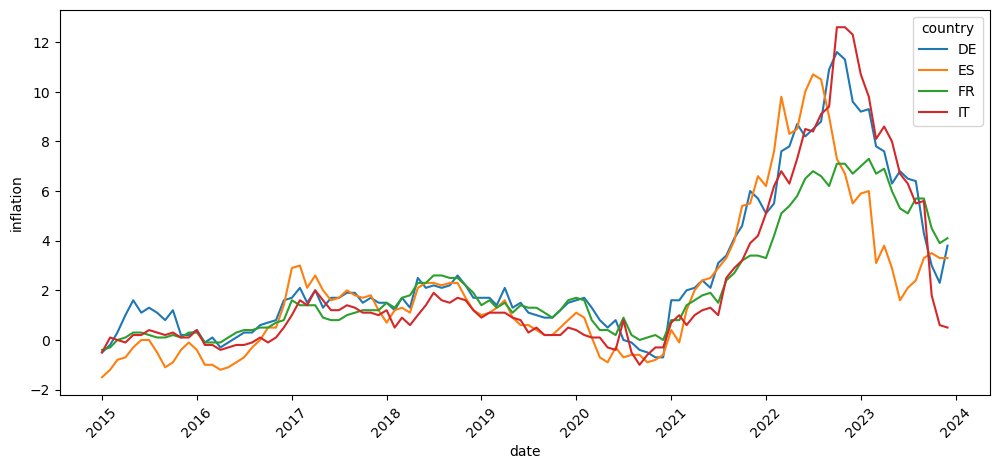

In [42]:
import matplotlib.dates as mdates

plt.figure(figsize=(12,5))
sns.lineplot(data=df, x="date", y="inflation", hue="country")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)
plt.show()

# Use this for presentation

#### Inflation over Time by Country by Year

In [43]:
# Use this for analysis
pip install plotly

SyntaxError: invalid syntax (4226892570.py, line 2)

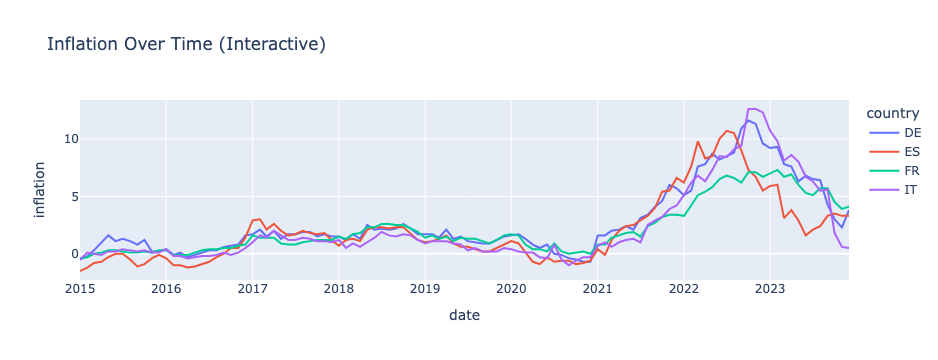

In [44]:
import plotly.express as px

fig = px.line(
    df,
    x="date",
    y="inflation",
    color="country",
    title="Inflation Over Time (Interactive)"
)

fig.show()

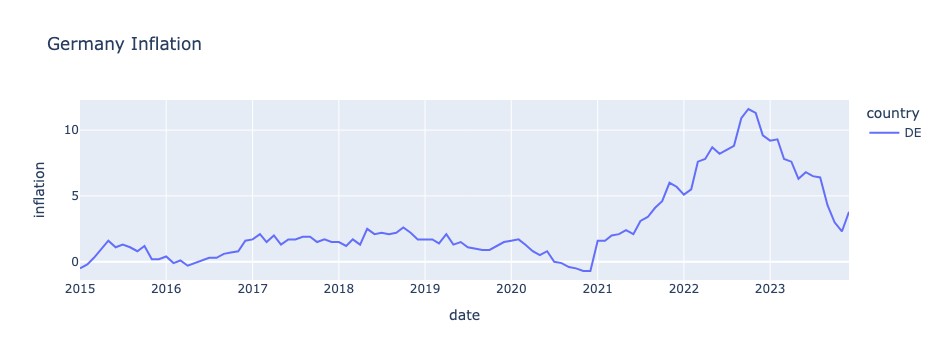

In [45]:
countries_selected = ["DE"]

df_filtered = df[df["country"].isin(countries_selected)]

fig = px.line(
    df_filtered,
    x="date",
    y="inflation",
    color="country",
    title="Germany Inflation"
)

fig.show()

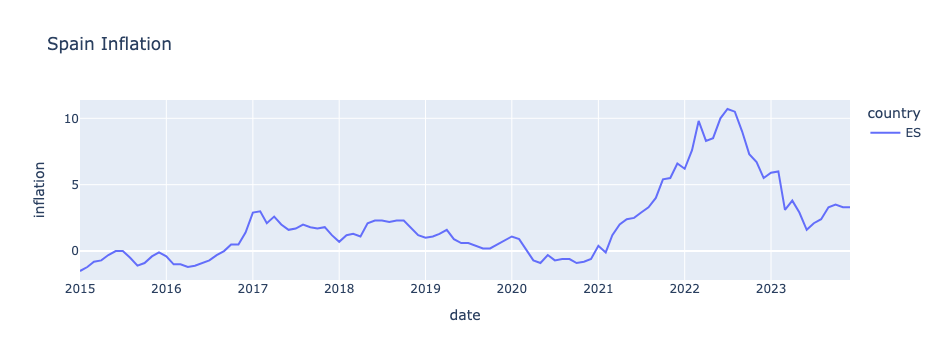

In [46]:
countries_selected = ["ES"]

df_filtered = df[df["country"].isin(countries_selected)]

fig = px.line(
    df_filtered,
    x="date",
    y="inflation",
    color="country",
    title="Spain Inflation"
)

fig.show()

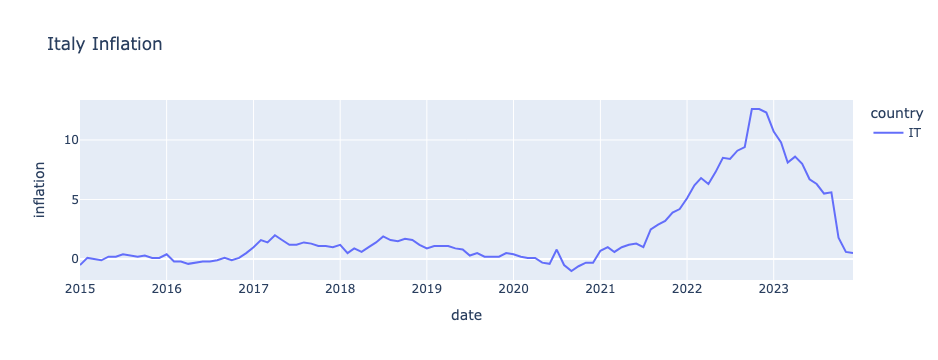

In [47]:
countries_selected = ["IT"]

df_filtered = df[df["country"].isin(countries_selected)]

fig = px.line(
    df_filtered,
    x="date",
    y="inflation",
    color="country",
    title="Italy Inflation"
)

fig.show()

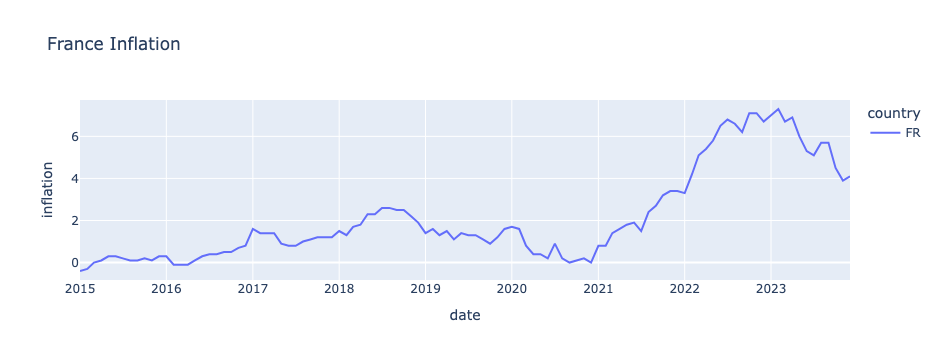

In [48]:
countries_selected = ["FR"]

df_filtered = df[df["country"].isin(countries_selected)]

fig = px.line(
    df_filtered,
    x="date",
    y="inflation",
    color="country",
    title="France Inflation"
)

fig.show()

---
### Volatility

In [49]:
df.groupby("country")["inflation"].std()

country
DE    2.959986
ES    2.861834
FR    2.184365
IT    3.271398
Name: inflation, dtype: float64

**Germany** shows the **highest** average inflation over the period, while **Spain** presents the **lowest**.

### Media

In [50]:
df.groupby("country")["inflation"].mean()

country
DE    2.708333
ES    2.000000
FR    2.129630
IT    2.203704
Name: inflation, dtype: float64